## Olist Marketplace Analysis
Analyzing Olist's 2016-2018 dataset to find what drives customer satisfaction.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
DATA = Path('data')


## Data Cleaning & Feature Engineering
We convert timestamps to dates, calculate delivery delays (actual vs. estimated), and merge product category English translations.

In [2]:
orders = pd.read_csv(DATA / 'olist_orders_dataset.csv')
customers = pd.read_csv(DATA / 'olist_customers_dataset.csv')
items = pd.read_csv(DATA / 'olist_order_items_dataset.csv')
payments = pd.read_csv(DATA / 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA / 'olist_order_reviews_dataset.csv')
products = pd.read_csv(DATA / 'olist_products_dataset.csv')
sellers = pd.read_csv(DATA / 'olist_sellers_dataset.csv')
categories = pd.read_csv(DATA / 'product_category_name_translation.csv')


## Checking the data

In [3]:
table_check = pd.DataFrame({
    'File': ['Orders', 'Customers', 'Items', 'Payments', 'Reviews', 'Products', 'Sellers'],
    'Rows': [len(orders), len(customers), len(items), len(payments), len(reviews), len(products), len(sellers)]
})
table_check


,File,Rows
0,Orders,99441
1,Customers,99441
2,Items,112650
3,Payments,103886
4,Reviews,99224
5,Products,32951
6,Sellers,3095


## Preparing dates

In [4]:
date_columns = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for column in date_columns:
    orders[column] = pd.to_datetime(orders[column])


## Adding item totals for each order

In [5]:
item_totals = items.groupby('order_id', as_index=False).agg(
    item_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    number_of_items=('order_item_id', 'count')
)

item_totals.head()


,order_id,item_value,freight_value,number_of_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


## Adding payment totals for each order

In [6]:
payment_totals = payments.groupby('order_id', as_index=False).agg(
    payment_value=('payment_value', 'sum'),
    installments=('payment_installments', 'max')
)

# This keeps the biggest payment method when an order has more than one payment method.
main_payment = payments.sort_values('payment_value', ascending=False).drop_duplicates('order_id')
main_payment = main_payment[['order_id', 'payment_type']]


## Keeping one review for each order

In [7]:
one_review = reviews.drop_duplicates('order_id')
one_review = one_review[['order_id', 'review_score']]


## Creating the main order table

In [8]:
order_data = orders.merge(customers, on='customer_id', how='left')
order_data = order_data.merge(item_totals, on='order_id', how='left')
order_data = order_data.merge(payment_totals, on='order_id', how='left')
order_data = order_data.merge(main_payment, on='order_id', how='left')
order_data = order_data.merge(one_review, on='order_id', how='left')

print('Number of orders:', len(order_data))
order_data.head()


Number of orders: 99441


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,item_value,freight_value,number_of_items,payment_value,installments,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,29.99,8.72,1.0,38.71,1.0,voucher,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,118.70,22.76,1.0,141.46,1.0,boleto,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,159.90,19.22,1.0,179.12,3.0,credit_card,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,45.00,27.20,1.0,72.20,1.0,credit_card,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,19.90,8.72,1.0,28.62,1.0,credit_card,5.0


## Creating delivery measures

In [9]:
order_data['delivery_days'] = (
    order_data['order_delivered_customer_date'] - order_data['order_purchase_timestamp']
).dt.total_seconds() / 86400

order_data['days_late_or_early'] = (
    order_data['order_delivered_customer_date'] - order_data['order_estimated_delivery_date']
).dt.total_seconds() / 86400

delivered_orders = order_data[
    (order_data['order_status'] == 'delivered') &
    (order_data['days_late_or_early'].notna())
]

delivered_orders['is_late'] = delivered_orders['days_late_or_early'] > 0
print('Delivered orders used for delivery analysis:', len(delivered_orders))


Delivered orders used for delivery analysis: 96470


## Question 1: Marketplace Trends Over Time
Calculated monthly order volume and Gross Merchandise Value (GMV) to see how the platform grew.

In [10]:
order_data['month'] = order_data['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly_result = order_data.groupby('month').agg(
    orders=('order_id', 'count'),
    revenue=('item_value', 'sum'),
    average_review=('review_score', 'mean')
).reset_index()

monthly_result.tail(12)


,month,orders,revenue,average_review
13,2017-11,7544,1010271.37,3.910027
14,2017-12,5673,743914.17,4.019066
15,2018-01,7269,950030.36,4.041105
16,2018-02,6728,844178.71,3.827188
17,2018-03,7211,983213.44,3.753078
18,2018-04,6939,996647.75,4.163591
19,2018-05,6873,996517.68,4.193888
20,2018-06,6167,865124.31,4.277479
21,2018-07,6292,895507.22,4.263166
22,2018-08,6512,854686.33,4.256130


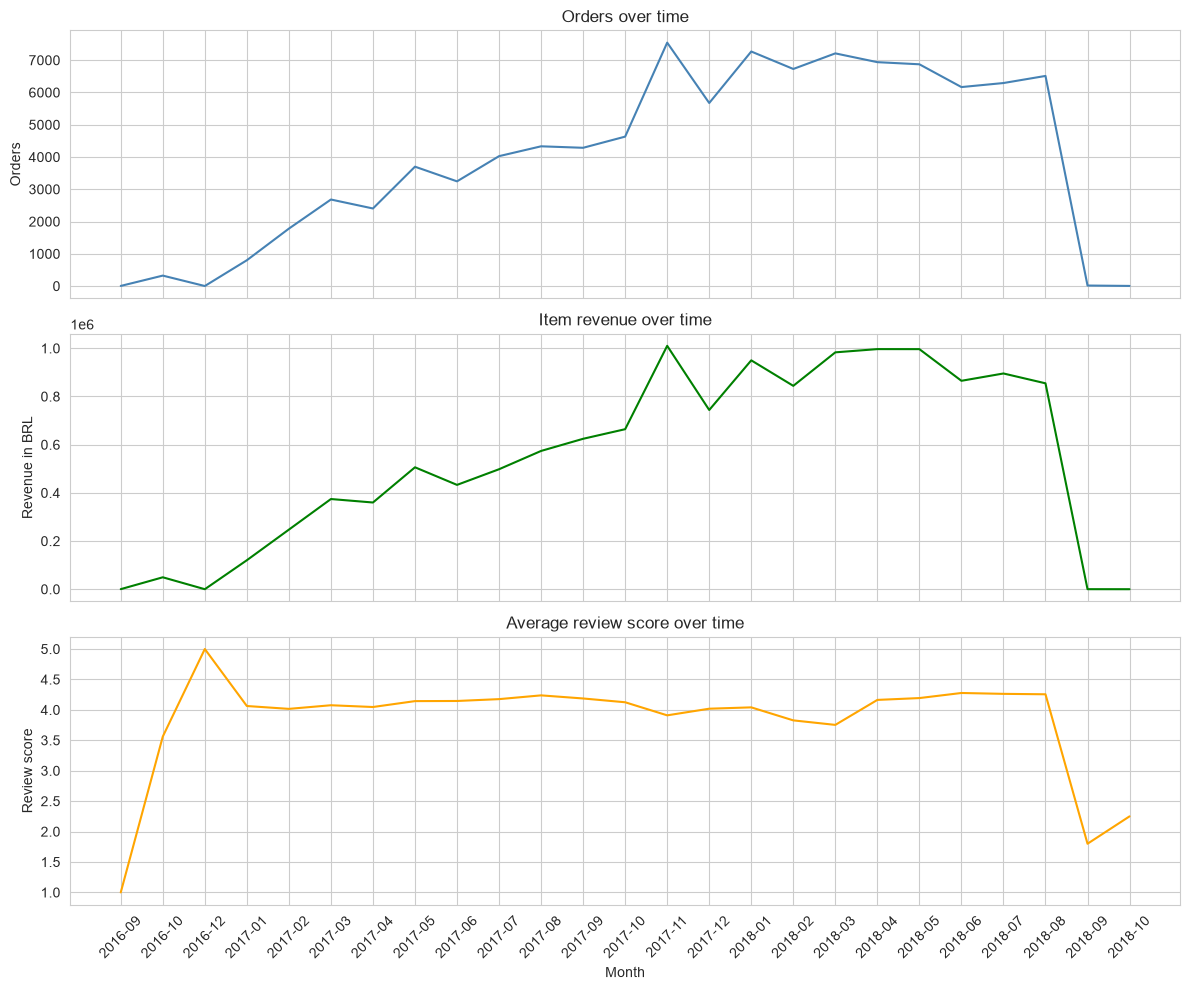

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(monthly_result['month'], monthly_result['orders'], color='steelblue')
axes[0].set_title('Orders over time')
axes[0].set_ylabel('Orders')

axes[1].plot(monthly_result['month'], monthly_result['revenue'], color='green')
axes[1].set_title('Item revenue over time')
axes[1].set_ylabel('Revenue in BRL')

axes[2].plot(monthly_result['month'], monthly_result['average_review'], color='orange')
axes[2].set_title('Average review score over time')
axes[2].set_ylabel('Review score')
axes[2].set_xlabel('Month')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Question 2: Delivery Timing vs. Review Scores
Categorized orders by delivery delay to see how late deliveries affect the 1-5 star customer ratings.

In [12]:
delivery_groups = [-np.inf, -7, -1, 0, 7, np.inf]
delivery_names = ['7+ days early', '1 to 7 days early', 'On time', '1 to 7 days late', 'More than 7 days late']

delivered_orders['delivery_group'] = pd.cut(
    delivered_orders['days_late_or_early'],
    bins=delivery_groups,
    labels=delivery_names
)

delivery_result = delivered_orders.groupby('delivery_group', observed=True).agg(
    orders=('order_id', 'count'),
    average_review=('review_score', 'mean'),
    low_review_rate=('review_score', lambda x: (x <= 2).mean())
).reset_index()

delivery_result


,delivery_group,orders,average_review,low_review_rate
0,7+ days early,71303,4.317275,0.089183
1,1 to 7 days early,15879,4.204574,0.101077
2,On time,1462,4.159310,0.109439
3,1 to 7 days late,4481,3.182127,0.355278
4,More than 7 days late,3345,1.729397,0.762332


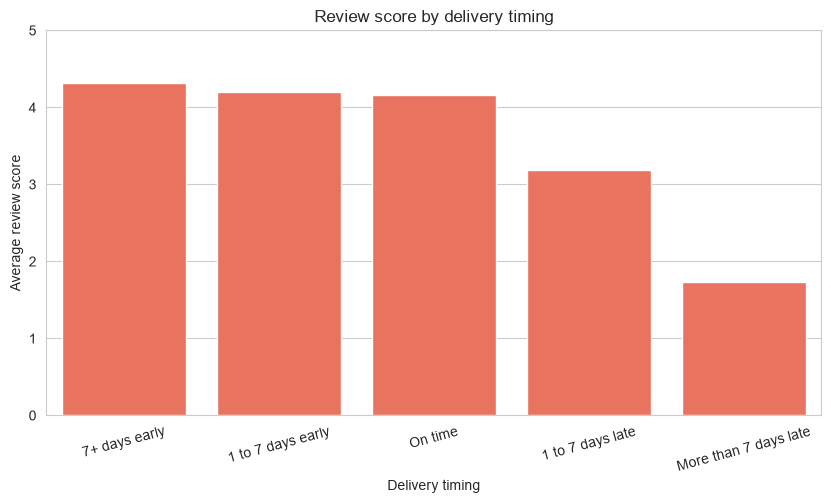

In [13]:
plt.figure(figsize=(10, 5))
sns.barplot(data=delivery_result, x='delivery_group', y='average_review', color='tomato')
plt.ylim(0, 5)
plt.title('Review score by delivery timing')
plt.xlabel('Delivery timing')
plt.ylabel('Average review score')
plt.xticks(rotation=15)
plt.show()


## Question 3: Geographic Patterns
Analyzed delivery delays and freight costs by customer state to identify regional logistics bottlenecks.

In [14]:
customer_state_result = order_data.groupby('customer_state').agg(
    orders=('order_id', 'count'),
    average_freight=('freight_value', 'mean'),
    average_review=('review_score', 'mean'),
    late_rate=('days_late_or_early', lambda x: (x > 0).mean())
).query('orders >= 500').sort_values('average_review')

customer_state_result


,orders,average_freight,average_review,late_rate
customer_state,,,,
MA,747,42.599689,3.757412,0.188755
PA,975,39.896186,3.846154,0.120000
CE,1336,36.436767,3.856712,0.146707
BA,3380,29.826289,3.861677,0.135207
RJ,12852,23.945252,3.876961,0.129474
PE,1652,36.073823,4.008563,0.104116
PB,536,48.345357,4.016981,0.106343
ES,2033,24.575111,4.038883,0.120020
GO,2020,26.464863,4.042850,0.079208


In [15]:
seller_orders = items.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')
seller_orders = seller_orders.merge(
    order_data[['order_id', 'review_score', 'days_late_or_early']],
    on='order_id',
    how='left'
)

seller_state_result = seller_orders.groupby('seller_state').agg(
    items=('order_item_id', 'count'),
    average_review=('review_score', 'mean'),
    late_rate=('days_late_or_early', lambda x: (x > 0).mean())
).query('items >= 300').sort_values('average_review')

seller_state_result


,items,average_review,late_rate
seller_state,,,
MA,405,4.000000,0.234568
ES,372,4.005450,0.064516
SP,80342,4.006251,0.083369
DF,899,4.032294,0.065628
PR,8671,4.073055,0.063199
BA,643,4.090484,0.052877
SC,4075,4.095179,0.057669
RJ,4818,4.101194,0.078871
MG,8827,4.107122,0.054039


## Question 4: Product Category Performance
Checked which product categories have the highest volume, prices, and average customer satisfaction scores.

In [16]:
category_data = items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
category_data = category_data.merge(categories, on='product_category_name', how='left')
category_data = category_data.merge(
    order_data[['order_id', 'review_score', 'days_late_or_early']],
    on='order_id',
    how='left'
)

category_data['category_name'] = category_data['product_category_name_english'].fillna('Unknown')


In [17]:
category_result = category_data.groupby('category_name').agg(
    items=('order_item_id', 'count'),
    revenue=('price', 'sum'),
    average_price=('price', 'mean'),
    average_review=('review_score', 'mean'),
    late_rate=('days_late_or_early', lambda x: (x > 0).mean())
).query('items >= 300').sort_values('average_review')

print('Categories with lower review scores')
display(category_result.head(10))

print('Categories with higher review scores')
display(category_result.tail(10).sort_values('average_review', ascending=False))


Categories with lower review scores


,items,revenue,average_price,average_review,late_rate
category_name,,,,,
office_furniture,1691,273960.70,162.011059,3.491950,0.088114
audio,364,50688.50,139.254121,3.830556,0.126374
Unknown,1627,185049.76,113.736792,3.833230,0.089121
home_confort,434,58572.04,134.958618,3.840278,0.101382
bed_bath_table,11115,1036988.68,93.296327,3.899017,0.082771
furniture_living_room,503,68916.56,137.011054,3.901606,0.077535
furniture_decor,8334,729762.49,87.564494,3.910061,0.082553
computers_accessories,7827,911954.32,116.513903,3.934336,0.075891
home_construction,604,83088.12,137.563113,3.938230,0.081126


Categories with higher review scores


,items,revenue,average_price,average_review,late_rate
category_name,,,,,
books_general_interest,553,46856.88,84.732152,4.446266,0.063291
luggage_accessories,1092,140429.98,128.598883,4.315257,0.053114
food,510,29393.41,57.634137,4.218182,0.096078
stationery,2517,230943.23,91.753369,4.196479,0.078665
pet_shop,1947,214315.41,110.074684,4.184306,0.060606
home_appliances,771,80171.53,103.983826,4.170573,0.066148
perfumery,3419,399124.87,116.737312,4.164758,0.071658
toys,4117,483946.60,117.548360,4.158952,0.072626
musical_instruments,680,191498.88,281.616000,4.151335,0.082353


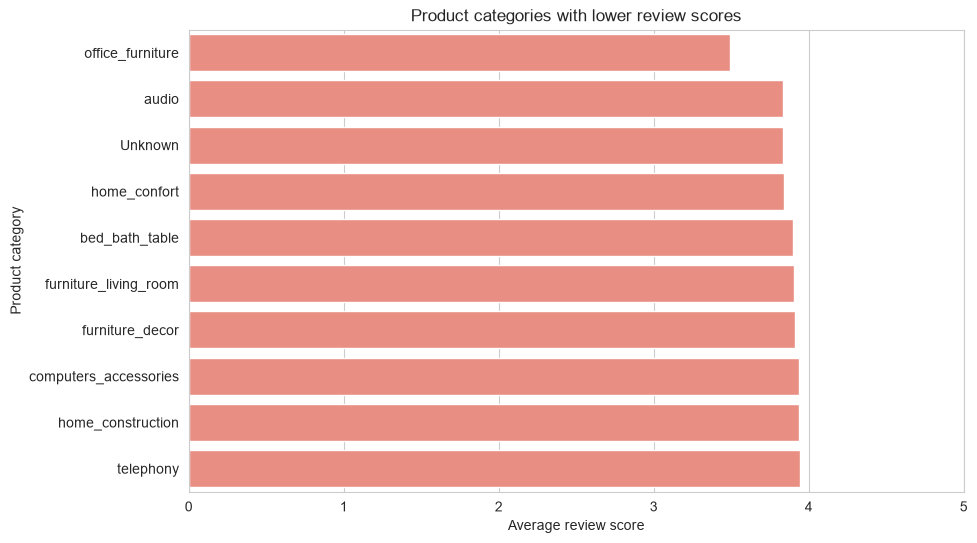

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=category_result.head(10).reset_index(), y='category_name', x='average_review', color='salmon')
plt.xlim(0, 5)
plt.title('Product categories with lower review scores')
plt.xlabel('Average review score')
plt.ylabel('Product category')
plt.show()


## Question 5: Payment Behavior
Explored how payment methods and average order values correlate with customer satisfaction.

In [19]:
payment_result = order_data.groupby('payment_type').agg(
    orders=('order_id', 'count'),
    average_order_value=('payment_value', 'mean'),
    average_review=('review_score', 'mean')
).sort_values('orders', ascending=False)

payment_result


,orders,average_order_value,average_review
payment_type,,,
credit_card,74975,167.289458,4.088667
boleto,19784,145.034435,4.086881
voucher,3151,120.293212,4.006729
debit_card,1527,142.724158,4.168968
not_defined,3,0.000000,1.666667


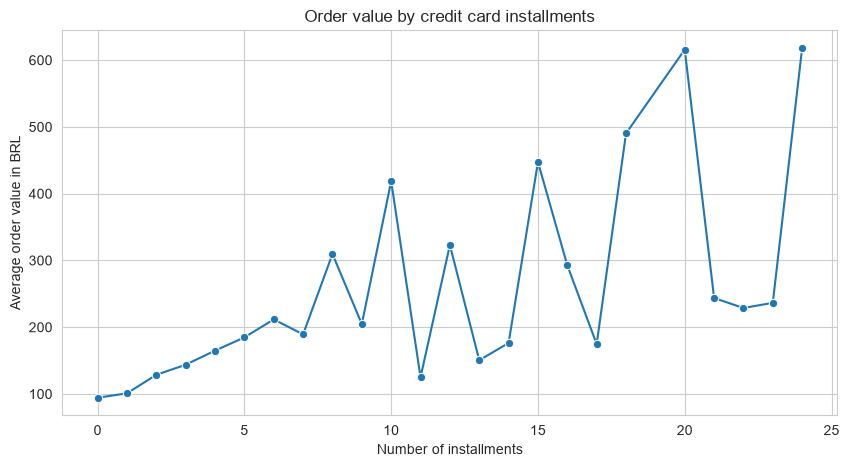

In [20]:
credit_card_result = order_data[order_data['payment_type'] == 'credit_card'].groupby('installments').agg(
    orders=('order_id', 'count'),
    average_order_value=('payment_value', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=credit_card_result, x='installments', y='average_order_value', marker='o')
plt.title('Order value by credit card installments')
plt.xlabel('Number of installments')
plt.ylabel('Average order value in BRL')
plt.show()


## Question 6: Root Cause Analysis
Isolated 1-2 star reviews to quantify the primary driver of customer dissatisfaction compared to 3-5 star reviews.

In [21]:
delivered_orders['low_review'] = delivered_orders['review_score'] <= 2

low_review_result = delivered_orders.groupby('low_review').agg(
    orders=('order_id', 'count'),
    average_delivery_days=('delivery_days', 'mean'),
    average_days_late_or_early=('days_late_or_early', 'mean'),
    late_rate=('is_late', 'mean'),
    average_freight=('freight_value', 'mean'),
    average_order_value=('item_value', 'mean')
)

low_review_result


,orders,average_delivery_days,average_days_late_or_early,late_rate,average_freight,average_order_value
low_review,,,,,,
False,84204,11.442743,-12.161098,0.043751,22.069714,133.698816
True,12266,20.215756,-4.430186,0.337681,27.701592,159.976672


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# 1. Predictive Modeling: Late Delivery Classifier
features = ['freight_value', 'item_value', 'delivery_days', 'number_of_items', 'payment_value']

model_df = delivered_orders.dropna(subset=['review_score', 'is_late'] + features).copy()

X = model_df[features]
y = model_df['is_late'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("--- LATE DELIVERY CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

# Feature Importance Output
importance_df = pd.DataFrame({'Feature': features, 'Importance': clf.feature_importances_}).sort_values(by='Importance', ascending=False)
print("\n--- TOP PREDICTIVE FEATURES ---")
print(importance_df)

--- LATE DELIVERY CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     17623
           1       0.78      0.58      0.67      1542

    accuracy                           0.95     19165
   macro avg       0.87      0.79      0.82     19165
weighted avg       0.95      0.95      0.95     19165


--- TOP PREDICTIVE FEATURES ---
           Feature  Importance
2    delivery_days    0.862853
0    freight_value    0.068890
4    payment_value    0.034365
1       item_value    0.029711
3  number_of_items    0.004182
